## Introduction
The purpose of this notebook to get the basic understanding of handle dataset, performing EDA, visualization of data and how different classification model works for the same data. I will be dealing with Iris dataset which is well-known to compare three models Logistic Regression, KNN and Decision Trees.
##### **Problem Statement**: Build classification model to classify Iris flowers categories 'Setosa' , 'Virginica' and Versicolor.
##### **Dataset Description**: The dataset has four main features (SepalLenght, SepalWidth, PetalLenght, PetalWidth) and an Id column (which we will be dropping).
##### **Purpose of this Notebook** : This notebook will give you an overview of basic level comparison of different classification models and how to work with data.
##### **Models we will be comparing**: Logistics Regression, Decision Trees, KNN

In [64]:
## All the important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score,confusion_matrix
##random seed
np.random.seed(42)
# pd.set_option("display.max_columns",40)

In [2]:
#loaded dataset
df = pd.read_csv("dataset/Iris.csv")
df = df.drop(columns="Id").copy()
print(f"1- Shape of the dataset after dropping ID column {df.shape}\n")
print(f"2- First 10 rows of the dataset:\n {df.head(10)}")

1- Shape of the dataset after dropping ID column (150, 5)

2- First 10 rows of the dataset:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa
5            5.4           3.9            1.7           0.4  Iris-setosa
6            4.6           3.4            1.4           0.3  Iris-setosa
7            5.0           3.4            1.5           0.2  Iris-setosa
8            4.4           2.9            1.4           0.2  Iris-setosa
9            4.9           3.1            1.5           0.1  Iris-setosa


In [3]:
#datatypes of every column
print(f"Data types of our columns: \n{df.dtypes}")

Data types of our columns: 
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object


In [4]:
#checkin for null values in every columns
print(f"Sum of Null values in our dataset: \n{df.isnull().sum()}")

Sum of Null values in our dataset: 
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


### **EDA**
In this section we will be working on EDA (Exploratory Data Analysis) which will give us insights on the data i.e., which columns to keep, how much data fluctuates, how data is distributed across classes etc. We will be working with different types of plots to see patterns in the data.

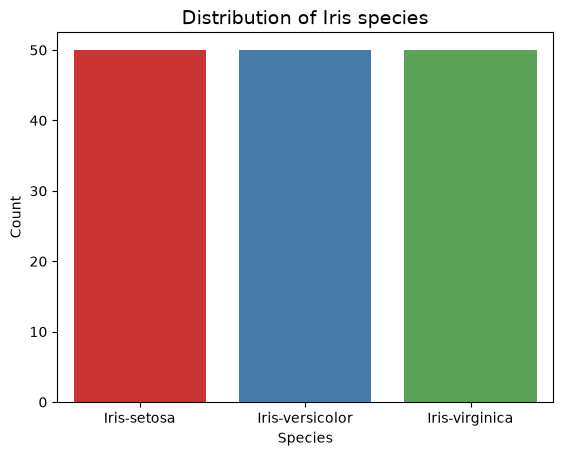

In [5]:
sns.countplot(data=df,x=df['Species'],hue=df['Species'],palette="Set1")
plt.title("Distribution of Iris species",fontsize=14)
plt.ylabel("Count")
plt.xlabel("Species")
plt.show()

In [42]:
df.groupby(df["Species"].where(df['Species']== 'Iris-versicolor')).describe()

SepalLengthCm                                            \
                        count   mean       std  min  25%  50%  75%  max   
Species                                                                   
Iris-versicolor          50.0  5.936  0.516171  4.9  5.6  5.9  6.3  7.0   

                SepalWidthCm                                             \
                       count  mean       std  min    25%  50%  75%  max   
Species                                                                   
Iris-versicolor         50.0  2.77  0.313798  2.0  2.525  2.8  3.0  3.4   

                PetalLengthCm                                            \
                        count  mean       std  min  25%   50%  75%  max   
Species                                                                   
Iris-versicolor          50.0  4.26  0.469911  3.0  4.0  4.35  4.6  5.1   

                PetalWidthCm                                            
                       count   mean       std  min  25%  50%  75%  max  
Species                                                                 
Iris-versicolor         50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8

### BOX PLOT 

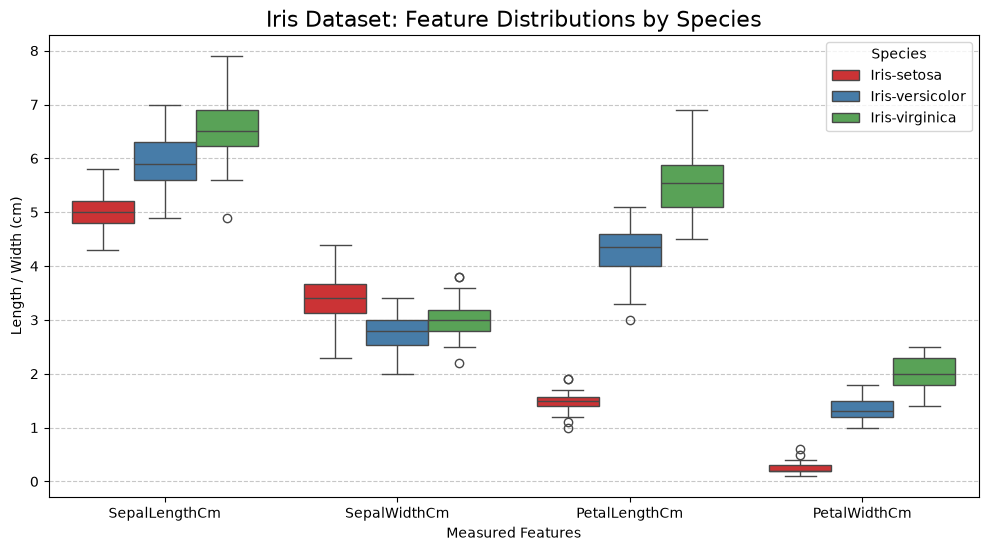

In [43]:

df_melted = df.melt(id_vars="Species",var_name="Features",value_name="cm")
plt.figure(figsize=(12,6))
sns.boxplot(data=df_melted,x="Features",y="cm",hue="Species",palette="Set1")
plt.title('Iris Dataset: Feature Distributions by Species', fontsize=16)
plt.xlabel('Measured Features')
plt.ylabel('Length / Width (cm)')
plt.legend(title='Species')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### SCATTER PLOT

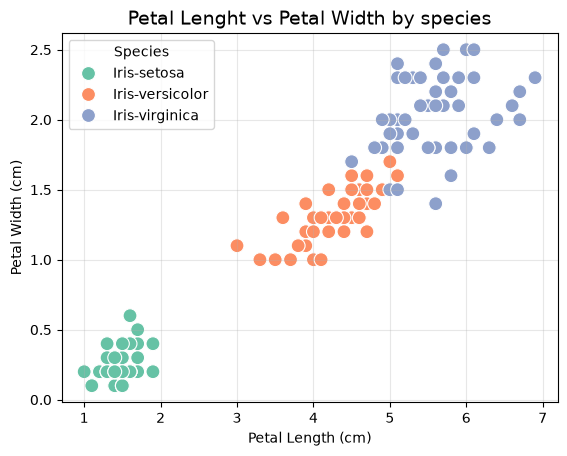

In [46]:
#Scatter plot
sns.scatterplot(data=df,x=df["PetalLengthCm"],y=df["PetalWidthCm"],hue="Species",palette="Set2",s=100)
plt.title("Petal Lenght vs Petal Width by species",fontsize=14)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(alpha=0.3)
plt.show()

### PAIR PLOT

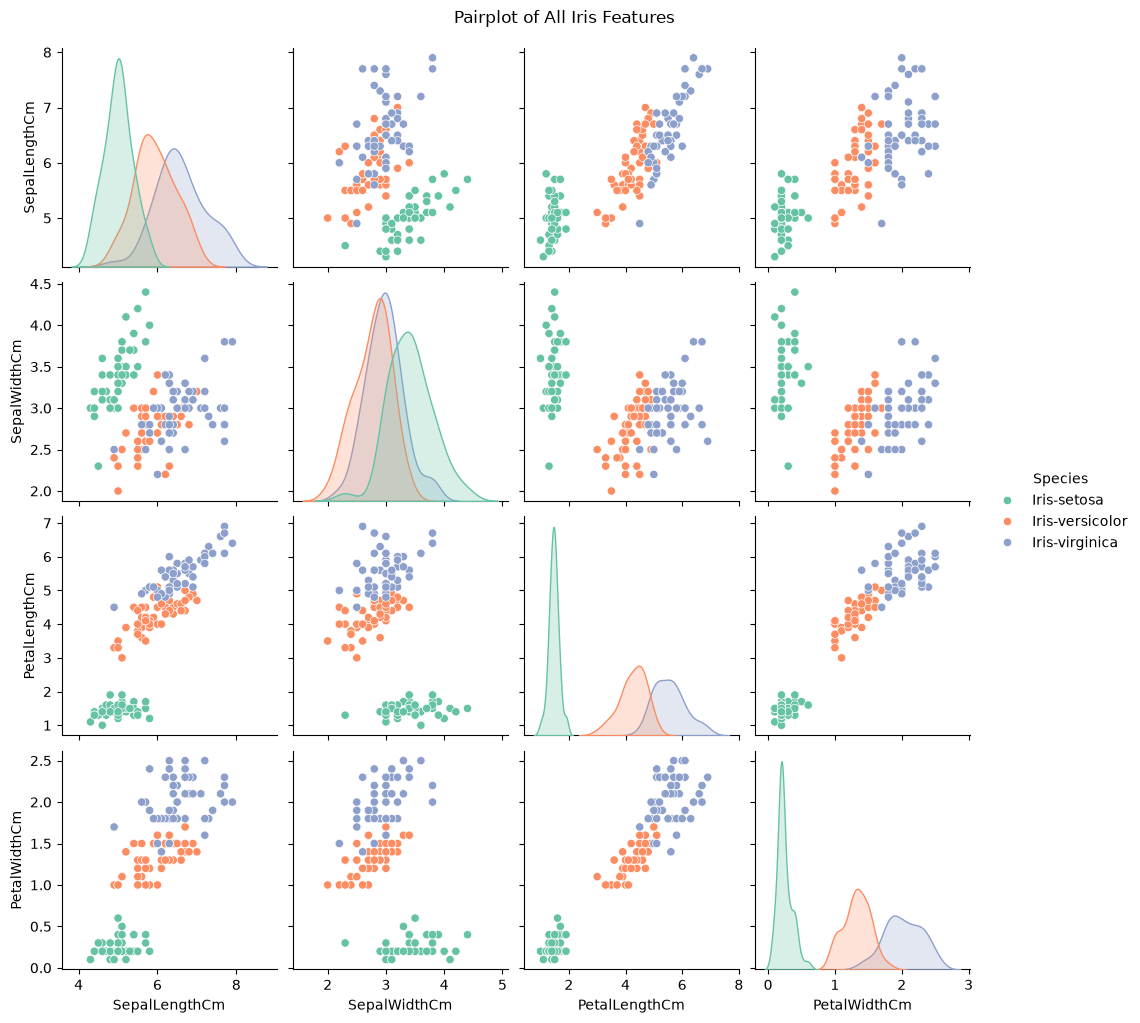

In [10]:
#pair plot
sns.pairplot(data=df,hue="Species",palette="Set2",diag_kind='kde')
plt.suptitle('Pairplot of All Iris Features', y=1.02) 
plt.show()

## EDA Summary: 
By performing EDA on the dataset, it is clear that "Setosa" is clearly distinguishable from the other two because of it's small size of petal lenght and width for better understanding look at the scatter plot you'll find setosa in a corner while the other two are closer to each other.

### FEATURE SELECTION, TRAIN, TEST AND SPLIT

In [56]:
#feature and label selection
X = df.drop(columns='Species')
y = df["Species"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"X_train lenght: {len(X_train)}\nX_test lenght: {len(X_test)}\ny_train lenght: {len(y_train)}\ny_test lenght: {len(y_test)}")

X_train lenght: 120
X_test lenght: 30
y_train lenght: 120
y_test lenght: 30


### ENCODING OF LABELS
Encoding of labels mean converting our String classes in to number like 0,1,2. 

In [ ]:
le = LabelEncoder()
y_train_encode = le.fit_transform(y_train)
y_test_encode = le.transform(y_test)
y_encoded = le.fit_transform(y) # whole y encoded because of cross-validation process

### SCALING 

In [13]:
#scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### TRAINING AND MODEL SELECTION (LOGISTIC REGRESSION)

In [15]:
model = LogisticRegression()
model.fit(X_train_scaled,y_train_encode)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [16]:
y_pred = model.predict(X_test_scaled)

In [17]:
# show_class(y_pred[7])
le.inverse_transform([y_pred[0]])[0]

'Iris-versicolor'

#### Accuracy 

In [18]:
print(f"Accuracy of LR: {model.score(X_test_scaled,y_test_encode):.4f}")


Accuracy of LR: 1.0000


#### Cross Validation

In [19]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('Lr',LogisticRegression())])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9600


### TRAINING AND MODEL SELECTION (KNN)

In [20]:
# KNN with 3 neighbors to look at
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_scaled,y_train_encode)

y_pred3 = knn3.predict(X_test_scaled)
#Accuracy Score
print(f"Accuracy with n_neighbors = 3 : {knn3.score(X_test_scaled,y_test_encode):.4f}")
#converting predicted class to string
le.inverse_transform([y_pred3[10]])[0]

Accuracy with n_neighbors = 3 : 1.0000


'Iris-virginica'

#### cross-validation for n = 3 neighbors

In [21]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=3))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9533


#### knn with 5 neighbors

In [22]:
#knn with 5 neighbors
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_scaled,y_train_encode)
y_pred5 = knn5.predict(X_test_scaled)
print(f"Accuracy with n_neighbors = 5 : {knn3.score(X_test_scaled,y_test_encode):.4f}")
le.inverse_transform([y_pred5[10]])[0]

Accuracy with n_neighbors = 5 : 1.0000


'Iris-virginica'

#### cross-validation for n = 5 neighbors

In [23]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=5))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9600


In [65]:
classification_report(y_true=y_test_encode,y_pred=y_pred5)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      1.00      1.00         9\n           2       1.00      1.00      1.00        11\n\n    accuracy                           1.00        30\n   macro avg       1.00      1.00      1.00        30\nweighted avg       1.00      1.00      1.00        30\n'

#### cross-validation for n = 7 neighbors

In [24]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=7))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9600


#### knn with 11 neighbors

In [25]:
#knn with 11 neighbors
knn11 = KNeighborsClassifier(n_neighbors=11)
knn11.fit(X_train_scaled,y_train_encode)
y_pred11 = knn11.predict(X_test_scaled)
print(f"Accuracy with n_neighbors = 11 : {knn3.score(X_test_scaled,y_test_encode):.4f}")
le.inverse_transform([y_pred11[10]])[0]

Accuracy with n_neighbors = 11 : 1.0000


'Iris-virginica'

#### cross-validation for n = 11 neighbors

In [26]:
pipeline = Pipeline([('scaler',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=11))])

scores = cross_val_score(pipeline,X,y_encoded,cv=5,scoring='accuracy')
# print(f"The accuracy score of cross-validation (5): {scores}")
print(f"Mean Score: {scores.mean():.4f}")

Mean Score: 0.9467


### Decision Tree

In [27]:
DTmodel = DecisionTreeClassifier(max_depth=3)
DTmodel.fit(X_train,y_train_encode)
y_pred = DTmodel.predict(X_test)
DTmodel.score(X_test,y_test_encode)

1.0

#### cross validation for decision tree

In [59]:
score = cross_val_score(DTmodel,X,y_encoded,cv=5)
print(f"Mean Score: {score.mean():.4f}")
print(f"Mean Score: {score.std():.4f}")

Mean Score: 0.9733
Mean Score: 0.0249
